# Model Training and Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier

df_train = pd.read_parquet('../data/model_train.parquet')
df_test = pd.read_parquet('../data/model_test.parquet')
print(f"Train: {df_train.shape}, Test: {df_test.shape}")

Train: (209140, 36), Test: (29360, 36)


Dropping the engineered features, that showed very little feature importance.

In [2]:
# Drop variables before training
cols_to_drop = [
    'product_change_flag', 'zombie_deal', 'chance_type_en', 'resp_change',
    'home_country', 'amount_changes', 'updates_last_30d'
]
cols_to_drop = [c for c in cols_to_drop if c in df_train.columns]
df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
print(f"Dropped: {cols_to_drop}")

Dropped: ['product_change_flag', 'zombie_deal', 'chance_type_en', 'resp_change', 'home_country', 'amount_changes', 'updates_last_30d']


In [3]:
# Data overview: target split and variable distributions
print("--- Target split (Won/Lost) ---")
print("Train:", df_train['target_won'].value_counts().to_dict())
print("Test:", df_test['target_won'].value_counts().to_dict())

if 'zombie_deal' in df_train.columns:
    n_zombie_train = (df_train['zombie_deal'] == 1).sum()
    n_zombie_test = (df_test['zombie_deal'] == 1).sum()
    print(f"\nObservations with zombie_deal=1: train={n_zombie_train}, test={n_zombie_test}")

print("\n--- Variable distributions (train) ---")
dist = df_train.describe(percentiles=[0.25, 0.5, 0.75]).T[['min', '25%', '50%', '75%', 'max', 'mean', 'std', 'count']]
dist.columns = ['min', 'q25', 'median', 'q75', 'max', 'mean', 'std', 'count']
display(dist)

--- Target split (Won/Lost) ---
Train: {1.0: 118100, 0.0: 91040}
Test: {1.0: 20850, 0.0: 8510}

--- Variable distributions (train) ---


,min,q25,median,q75,max,mean,std,count
business_unit,0.000000e+00,2.000000,2.000000,4.000000,6.000000e+00,2.592225,1.644207e+00,209140.0
responsible,0.000000e+00,50.000000,80.000000,118.000000,1.630000e+02,81.066836,4.461079e+01,209140.0
registered_by_id,0.000000e+00,62.000000,91.000000,133.000000,1.860000e+02,93.869719,4.976484e+01,209140.0
updated_by_id,0.000000e+00,60.000000,95.000000,144.000000,2.000000e+02,102.066291,5.638655e+01,209140.0
stage_en,0.000000e+00,1.000000,7.000000,7.000000,8.000000e+00,4.399603,2.956658e+00,209140.0
probability,1.098901e-02,0.109890,0.439560,0.659341,9.890110e-01,0.407564,2.832284e-01,209140.0
amount,8.597428e-01,767.462755,9455.399867,50091.467061,5.782067e+07,182394.872599,1.153931e+06,209140.0
org_id,0.000000e+00,736.000000,1724.000000,2598.000000,3.594000e+03,1728.660051,1.084519e+03,209140.0
org_category_en,0.000000e+00,0.000000,0.000000,2.000000,7.000000e+00,0.807880,1.415762e+00,209140.0
intercompany_flag,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,209140.0


In [4]:
target_col = 'target_won'
# Drop rows with NaN in target (sklearn models require finite y)
df_train = df_train.dropna(subset=[target_col])
df_test = df_test.dropna(subset=[target_col])

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"NA count train: {X_train.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")

X_train: (209140, 28), X_test: (29360, 28)
NA count train: 0, test: 0


## Model Training

In [5]:
# # Logistic Regression: class_weight='balanced', fit on scaled data
# lr_model = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
# lr_model.fit(X_train_scaled, y_train)

# # Random Forest: RandomizedSearchCV with class_weight
# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# rf_param_grid = {
#     'n_estimators': [200, 300, 500],
#     'max_depth': [10, 20, 30, None],
#     'min_samples_leaf': [1, 2, 5],
#     'class_weight': ['balanced', 'balanced_subsample']
# }
# rf_search = RandomizedSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_distributions=rf_param_grid,
#     n_iter=15, cv=3, scoring='roc_auc', random_state=42
# )
# rf_search.fit(X_train, y_train)
# rf_model = rf_search.best_estimator_
# print(f"RF best params: {rf_search.best_params_}")

# # XGBoost: RandomizedSearchCV with scale_pos_weight
# xgb_param_grid = {
#     'n_estimators': [200, 300, 500],
#     'max_depth': [4, 6, 8, 10],
#     'learning_rate': [0.05, 0.1, 0.2],
#     'scale_pos_weight': [scale_pos_weight]
# }
# xgb_search = RandomizedSearchCV(
#     XGBClassifier(random_state=42, eval_metric='logloss'),
#     param_distributions=xgb_param_grid,
#     n_iter=15, cv=3, scoring='roc_auc', random_state=42
# )
# xgb_search.fit(X_train, y_train)
# xgb_model = xgb_search.best_estimator_
# print(f"XGB best params: {xgb_search.best_params_}")

# print("Models trained.")

In [6]:
# Original model training code (before class weights, scaling, hyperparameter tuning)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("Models trained.")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Models trained.


## Evaluation

Logistic Regression: AUC = 0.7147
Random Forest: AUC = 0.8197
XGBoost: AUC = 0.7946


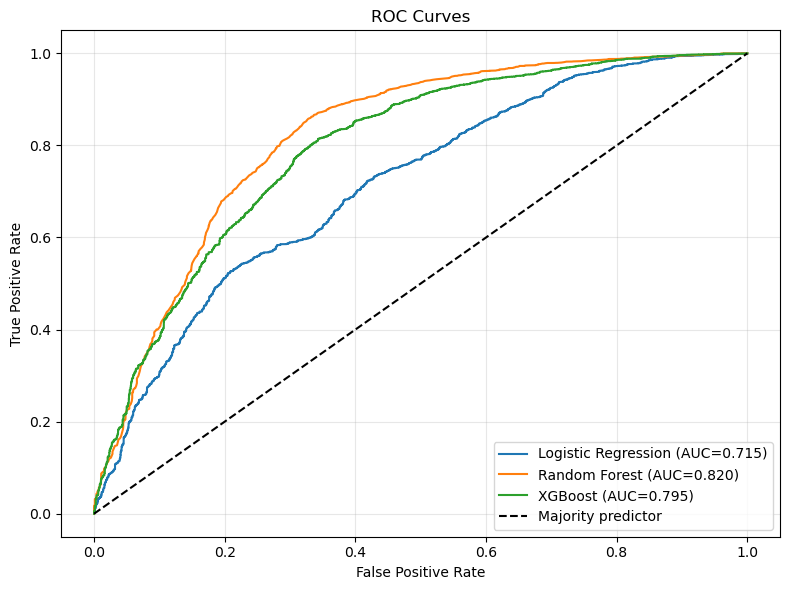

In [7]:
models = [
    ('Logistic Regression', lr_model, X_test_scaled),
    ('Random Forest', rf_model, X_test),
    ('XGBoost', xgb_model, X_test)
]
for name, mdl, X_eval in models:
    y_prob = mdl.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"{name}: AUC = {auc:.4f}")

plt.figure(figsize=(8, 6))
for name, mdl, X_eval in models:
    y_prob = mdl.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.3f})')
# Majority class predictor: compute ROC and AUC from data
majority_class = y_train.value_counts().idxmax()
majority_label = 'Won' if majority_class == 1 else 'Lost'
# All samples get same score (majority class) -> ROC curve is diagonal
majority_scores = np.full(len(y_test), float(majority_class))
fpr_maj, tpr_maj, _ = roc_curve(y_test, majority_scores)
auc_maj = roc_auc_score(y_test, majority_scores)
plt.plot(fpr_maj, tpr_maj, 'k--', label=f'Majority predictor')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

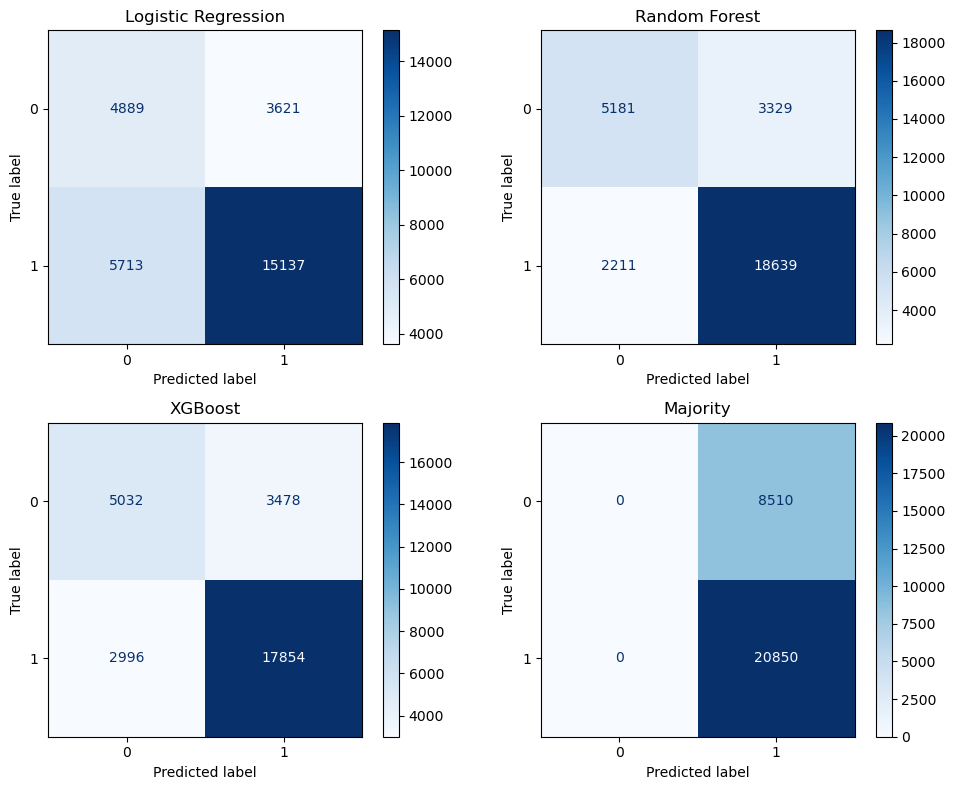

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
all_models = list(models) + [('Majority', None, None)]
for ax, (name, mdl, X_eval) in zip(axes.flat, all_models):
    if mdl is None:
        y_pred = np.full(len(y_test), majority_class)
    else:
        y_pred = mdl.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [9]:
for name, mdl, X_eval in models:
    y_pred = mdl.predict(X_eval)
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred, target_names=['Lost', 'Won']))

# Majority predictor
y_pred_majority = np.full(len(y_test), majority_class)
print(f"\nMajority (always predict {majority_label}):")
print(classification_report(y_test, y_pred_majority, target_names=['Lost', 'Won']))


Logistic Regression:
              precision    recall  f1-score   support

        Lost       0.46      0.57      0.51      8510
         Won       0.81      0.73      0.76     20850

    accuracy                           0.68     29360
   macro avg       0.63      0.65      0.64     29360
weighted avg       0.71      0.68      0.69     29360


Random Forest:
              precision    recall  f1-score   support

        Lost       0.70      0.61      0.65      8510
         Won       0.85      0.89      0.87     20850

    accuracy                           0.81     29360
   macro avg       0.77      0.75      0.76     29360
weighted avg       0.81      0.81      0.81     29360


XGBoost:
              precision    recall  f1-score   support

        Lost       0.63      0.59      0.61      8510
         Won       0.84      0.86      0.85     20850

    accuracy                           0.78     29360
   macro avg       0.73      0.72      0.73     29360
weighted avg       0.78   

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# Feature importance: Random Forest and XGBoost (all variables)
print("--- Feature importance by model ---")
for name, mdl in [('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    feat_imp = pd.DataFrame({'feature': X_train.columns, 'importance': mdl.feature_importances_})
    feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)
    print(f"\n{name}:")
    display(feat_imp)

--- Feature importance by model ---

Random Forest:


,feature,importance
0,amount,0.129608
1,saledate_delta,0.108387
2,probability,0.072792
3,deal_share_rep,0.072135
4,rep_amount,0.065430
5,rep_closing_rate,0.062027
6,customer_win_ratio,0.060507
7,org_id,0.055272
8,days_since_last_update,0.038836
9,deal_age,0.037629



XGBoost:


,feature,importance
0,saledate_delta,0.085976
1,deal_age,0.079012
2,probability,0.079002
3,amount,0.066707
4,has_products_and_services,0.061292
5,days_since_last_update,0.058477
6,customer_win_ratio,0.048399
7,business_unit,0.041492
8,org_category_en,0.038805
9,deal_share_rep,0.037583


In [11]:
# Results by decision threshold (0.5 to 0.9)
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = np.arange(0.4, 0.95, 0.05)
rows = []
for name, mdl, X_eval in models:
    y_prob = mdl.predict_proba(X_eval)[:, 1]
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        rows.append({
            'model': name,
            'threshold': thresh,
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'accuracy': accuracy_score(y_test, y_pred)
        })
df_threshold = pd.DataFrame(rows)
display(df_threshold.round(4))

,model,threshold,precision,recall,f1,accuracy
0,Logistic Regression,0.40,0.7101,1.0000,0.8305,0.7101
1,Logistic Regression,0.45,0.7343,0.9905,0.8433,0.7387
2,Logistic Regression,0.50,0.8070,0.7260,0.7643,0.6821
3,Logistic Regression,0.55,0.8878,0.0896,0.1628,0.3454
4,Logistic Regression,0.60,0.9219,0.0028,0.0056,0.2917
5,Logistic Regression,0.65,1.0000,0.0003,0.0006,0.2901
6,Logistic Regression,0.70,0.0000,0.0000,0.0000,0.2899
7,Logistic Regression,0.75,0.0000,0.0000,0.0000,0.2899
8,Logistic Regression,0.80,0.0000,0.0000,0.0000,0.2899
9,Logistic Regression,0.85,0.0000,0.0000,0.0000,0.2899


## Forecast DataFrame for Open Chances (Task 3 Input)

Using the full chance changelog, we construct a clean forecast input by applying the following steps:

1. **Identify currently open chances** — take the latest changelog entry per `chance_id` and retain only those whose final status is *Open*.
2. **Remove stale chances** — exclude any chance not updated within the last year (relative to 2026-01-01), as these are unlikely to be actively pursued.
3. **Fix backdated sale dates** — if a chance has a `saledate` in the past (before 2026-01-01), replace it with 2026-01-07 as a conservative near-term placeholder.
4. **Amount distribution overview** — print a bucketed breakdown (< 10, 10–100, 100–1k, 1k–10k, ≥ 10k) of the raw amounts before any imputation.
5. **Impute low amounts** — replace amounts below `AMOUNT_FLOOR` (configurable at the top of the cell) with the median amount of the corresponding business unit.
6. **Label-encode categoricals** — apply `LabelEncoder` to string columns, fitting on the full changelog to ensure consistent integer mappings with the training data.
7. **Drop non-feature columns** — remove the same low-importance and non-feature columns that were excluded during model training.
8. **Align & impute** — reindex to exactly match the training feature set and apply the fitted `SimpleImputer` (median strategy) to fill any remaining missing values.
9. **Predict win probability** — use the trained Random Forest model to generate a `forecast_prob_won` score for each open chance.
10. **Assemble & save output** — combine predictions with the original metadata to produce `forecast_won_lost` (9 columns required by Task 3) and write it to `data/forecast_won_lost.parquet`.

In [16]:
# ─── Build forecast_won_lost: open chances with RF-predicted win probabilities ──

from sklearn.preprocessing import LabelEncoder

# ── CONFIGURABLE THRESHOLD ────────────────────────────────────────────────────
AMOUNT_FLOOR = 150   # amounts strictly below this are replaced by BU median
# ─────────────────────────────────────────────────────────────────────────────

# 1. Load changelog, take latest entry per chance, then keep only those still Open
df_cl = pd.read_parquet('../data/newfeats_repvars_chance_changelog.parquet')
df_open = (
    df_cl
    .sort_values('updated_dt')
    .groupby('chance_id', as_index=False)
    .last()
    .copy()
)
df_open = df_open[df_open['status'] == 'Open'].reset_index(drop=True)
print(f"Chances open at last entry:          {len(df_open):,}")

# 2. Exclude chances not updated in the last year (stale as of 2026-01-01)
cutoff_date = pd.Timestamp('2026-01-01')
stale_mask = df_open['updated_dt'] < (cutoff_date - pd.DateOffset(years=1))
df_open = df_open[~stale_mask].reset_index(drop=True)
print(f"After removing stale (>1yr):         {len(df_open):,}")

# 3. If saledate is before 2026-01-01, set it to 2026-01-07
df_open['saledate'] = pd.to_datetime(df_open['saledate'])
df_open.loc[df_open['saledate'] < cutoff_date, 'saledate'] = pd.Timestamp('2026-01-07')
print(f"Saledates backdated → set to 7 Jan:  {(df_open['saledate'] == pd.Timestamp('2026-01-07')).sum():,}")

# 4. Amount distribution overview (before imputation)
bins   = [0, 10, 100, 1_000, 10_000, np.inf]
labels = ['< 10', '10–100', '100–1k', '1k–10k', '≥ 10k']
dist   = pd.cut(df_open['amount'], bins=bins, labels=labels, right=False).value_counts().reindex(labels)
print(f"\nAmount distribution (n={len(df_open):,}):")
for lbl, cnt in dist.items():
    print(f"  {lbl:<10} {cnt:>5,}  ({cnt/len(df_open)*100:.1f}%)")

# 5. Fill low amounts with business_unit median
bu_medians = df_open.groupby('business_unit')['amount'].median()
low_mask   = df_open['amount'] < AMOUNT_FLOOR
df_open.loc[low_mask, 'amount'] = df_open.loc[low_mask, 'business_unit'].map(bu_medians)
print(f"\nAmounts below {AMOUNT_FLOOR:,} filled with BU median: {low_mask.sum():,}")

# 6. Save metadata with original string labels for Task 3 output
meta = df_open[['chance_id', 'amount', 'saledate', 'business_unit', 'responsible',
                'close_date_shift', 'updated_dt', 'registered_dt']].copy()

# 7. Label-encode categoricals — fit on full changelog (same strategy as training)
cat_cols = ['business_unit', 'responsible', 'registered_by_id', 'updated_by_id',
            'stage_en', 'org_id', 'org_category_en']
for col in cat_cols:
    if col in df_cl.columns:
        le = LabelEncoder()
        le.fit(df_cl[col].fillna('missing').astype(str))
        df_open[col] = le.transform(df_open[col].fillna('missing').astype(str))

# 8. Drop same columns as in training (low-importance + non-feature)
cols_to_drop_open = [
    'product_change_flag', 'zombie_deal', 'chance_type_en', 'resp_change',
    'home_country', 'amount_changes', 'updates_last_30d',
    'target_won', 'status', 'chance_id', 'registered_dt', 'updated_dt',
    'saledate', 'org_country', 'days_until_saledate',
]
cols_to_drop_open = [c for c in cols_to_drop_open if c in df_open.columns]
X_open = df_open.drop(columns=cols_to_drop_open)

# 9. Align to exact training columns and impute with the fitted SimpleImputer
X_open = X_open.reindex(columns=X_train.columns, fill_value=np.nan)
X_open_imp = pd.DataFrame(imputer.transform(X_open), columns=X_open.columns, index=X_open.index)

# 10. Predict win probability with Random Forest
forecast_prob_won = rf_model.predict_proba(X_open_imp)[:, 1]

# 11. Assemble forecast_won_lost with Task 3 columns
forecast_won_lost = meta.copy()
forecast_won_lost['forecast_prob_won'] = forecast_prob_won
forecast_won_lost = forecast_won_lost[[
    'chance_id', 'amount', 'forecast_prob_won', 'saledate',
    'business_unit', 'responsible', 'close_date_shift',
    'updated_dt', 'registered_dt'
]]

print(f"\nforecast_won_lost shape:             {forecast_won_lost.shape}")
print(f"forecast_prob_won range:             {forecast_won_lost['forecast_prob_won'].min():.3f} – {forecast_won_lost['forecast_prob_won'].max():.3f}")
print(f"Null values:                         {forecast_won_lost.isnull().sum().sum()}")
display(forecast_won_lost.head())

# 12. Save to parquet for use in other notebooks
forecast_won_lost.to_parquet('../data/forecast_won_lost.parquet', index=False)
print("\nSaved → ../data/forecast_won_lost.parquet")

Chances open at last entry:          5,492
After removing stale (>1yr):         1,734
Saledates backdated → set to 7 Jan:  153

Amount distribution (n=1,734):
  < 10         118  (6.8%)
  10–100       116  (6.7%)
  100–1k        63  (3.6%)
  1k–10k       250  (14.4%)
  ≥ 10k      1,187  (68.5%)

Amounts below 150 filled with BU median: 235

forecast_won_lost shape:             (1734, 9)
forecast_prob_won range:             0.008 – 0.914
Null values:                         0


,chance_id,amount,forecast_prob_won,saledate,business_unit,responsible,close_date_shift,updated_dt,registered_dt
0,001e7a5151ff24c0,15972.889958,0.764,2026-03-17 09:40:15,ac2a5ee6878db2c2,aa551401d67d6c75,0,2025-12-17 11:49:22,2025-12-17 08:41:59
1,003c407f17a994b6,20516.267688,0.298,2026-03-31 00:00:00,6befd145c261113d,e2bd0ec40a790867,2,2025-11-21 17:44:41,2025-05-08 12:45:10
2,004ddea55262ae2c,59820.408924,0.410,2026-01-30 12:51:21,a66943a59bca7bfd,4f0e40cb4229b152,0,2025-10-30 11:54:19,2025-10-30 11:54:17
3,0070efc1485bb975,48317.272338,0.182,2026-01-07 00:00:00,ac2a5ee6878db2c2,9e271d581fe9a5f9,3,2025-07-03 14:00:45,2024-09-16 07:51:49
4,00a71a2e37b27bfd,9548.177348,0.456,2026-06-30 00:00:00,9387d1da6d5967e1,493efc31b09f958f,5,2025-10-30 15:57:59,2024-04-08 15:28:17



Saved → ../data/forecast_won_lost.parquet
